In [17]:
import numpy as np
import matplotlib.pyplot as plt
import h5py

from sklearn import preprocessing

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as torchdata
from astroML.utils.decorators import pickle_results

from sklearn.model_selection import KFold

from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc

%config InlineBackend.figure_format='retina'
plt.rc('text', usetex=True)

In [18]:
data = h5py.File('gw.h5')

In [19]:
keys = ['chi1x', 'chi1y','chi1z', 'chi2x', 'chi2y', 'chi2z', 'dec', 'iota', 'mtot', 'psi', 'q', 'ra', 'z' ]
X = np.column_stack([data[k][:10000] for k in keys])
y = data['det'][:10000]

In [20]:
scaler = preprocessing.StandardScaler() # working column-wise
scaler.fit(X)
X = scaler.transform(X)

In [21]:
# split data into 9:1 train:test
dataset = torchdata.TensorDataset(
    torch.tensor(X, dtype=torch.float32),
    torch.tensor(y, dtype=torch.float32).view(-1,1)
)
trainnum = X.shape[0] // 10 * 9
traindata, testdata = torchdata.random_split(dataset, 
                                             [trainnum, X.shape[0] - trainnum])
traindataloader = torchdata.DataLoader(traindata, 
                                       batch_size=128, 
                                       shuffle=True)

In [22]:
# define structure of neural net
class Net(nn.Module):
    def __init__(self, nhidden):
        super(Net, self).__init__()
        self.fc_h = nn.Linear(13, nhidden)
        self.fc_o = nn.Linear(nhidden, 1)

    def forward(self, x):
        h = torch.sigmoid(self.fc_h(x)) # using sigmoid activation function
        z = self.fc_o(h)
        return z

In [36]:
def train_NN(nneurons, tr_data_load, tr_data, test_data):
    # 6 hidden neurons
    model = Net(nneurons)
    # MSE loss
    #n_pos = (y == 1).sum()
    #n_neg = (y == 0).sum()
    labels = torch.stack([tr_data[i][1] for i in range(len(tr_data))]).view(-1)
    n_pos = (labels == 1).sum().item()
    n_neg = (labels == 0).sum().item()
    pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32) 
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)    # logistic loss for classification
    # stochastic gradient descent
    optimizer = torch.optim.SGD(model.parameters(), lr=0.001) 
    # Adaptive learning rate...
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer,  
                                                           patience=5, 
                                                           threshold=1e-3)

    min_valid_loss = float('inf')
    badepochs = 0
    for t in range(50):
        train_loss = 0
        for i, databatch in enumerate(tr_data_load, 0):
            features, det = databatch
            optimizer.zero_grad() # Initalize optimizer
            det_pred = model(features) # Predictions
            loss = criterion(det_pred, det) # Compute loss
            loss.backward() # Backpropagation 
            optimizer.step() # Step in gradient descent
            train_loss += loss.item() # Update loss

        with torch.no_grad():
            #features = test_data[:][0]
            #det = test_data[:][1]
            features = torch.stack([test_data[i][0] for i in range(len(test_data))])
            det = torch.stack([test_data[i][1] for i in range(len(test_data))])
            det_pred = model(features)
            valid_loss = criterion(det_pred, det)
            #if t % 10 == 0:
                #print('Epoch %3i: train loss %0.3e validation loss %0.3e' % (t, \
                        #train_loss / len(tr_data), valid_loss / len(test_data)))
            # stop training if validation loss has not fallen in 10 epochs
            if valid_loss > min_valid_loss*(1-1e-3):
                badepochs += 1
            else:
                min_valid_loss = valid_loss
                badepochs = 0
            if badepochs == 10:
                print('Finished training')
                break
        scheduler.step(valid_loss)
    return model

In [37]:
model = train_NN(6, traindataloader, traindata, testdata)

In [38]:
model.eval()

with torch.no_grad():
    X_test = testdata[:][0]
    y_test = testdata[:][1].numpy().ravel()

    logits = model(X_test)

    probs = torch.sigmoid(logits).numpy().ravel()

y_pred = (probs >= 0.5).astype(int)

In [39]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[477 388]
 [ 49  86]]


AUC = 0.638766859344894


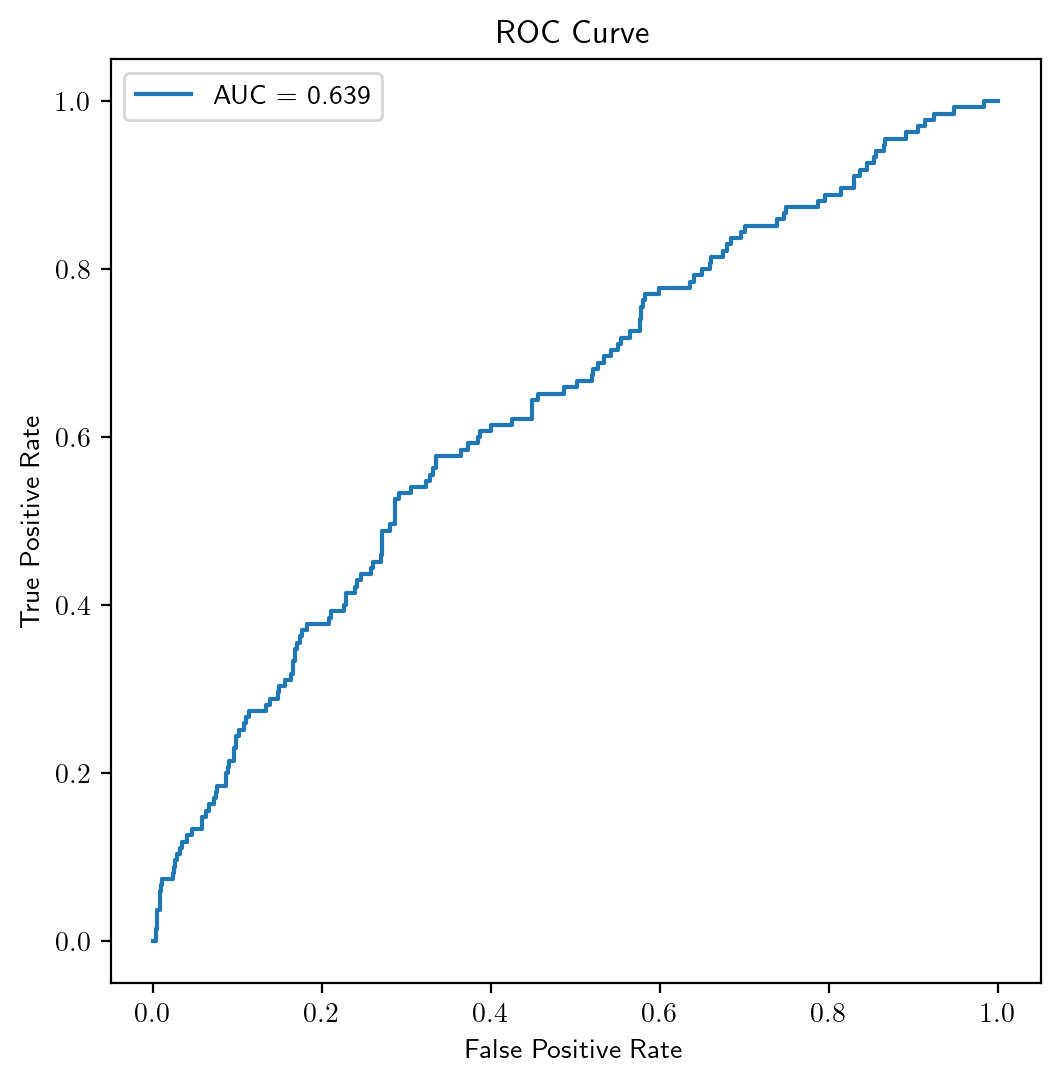

In [40]:
fpr, tpr, _ = roc_curve(y_test, probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

print("AUC =", roc_auc)

## Cross validation

In [41]:
# split data into 9:1 train:test
dataset = torchdata.TensorDataset(
    torch.tensor(X, dtype=torch.float32),
    torch.tensor(y, dtype=torch.float32).view(-1,1)
)
trainnum = X.shape[0] // 10 * 9
traindata, testdata = torchdata.random_split(dataset, 
                                             [trainnum, X.shape[0] - trainnum])
traindataloader = torchdata.DataLoader(traindata, 
                                       batch_size=128, 
                                       shuffle=True)

In [42]:
def kfold_cv(trdata, nneur):

    kf = KFold(n_splits=5, shuffle=True)

    eps_cv = []

    for train, val in kf.split(trdata):

        Xtr = torchdata.Subset(trdata, train)
        Xval = torchdata.Subset(trdata, val)
        traindataloader = torchdata.DataLoader(Xtr, batch_size=128, shuffle=True)

        mdl = train_NN(nneur, traindataloader, Xtr, Xval)

        with torch.no_grad():
            X_val = torch.stack([Xval[i][0] for i in range(len(Xval))])
            y_val = torch.stack([Xval[i][1] for i in range(len(Xval))]).numpy().ravel()

            logits = mdl(X_val)

            probs = torch.sigmoid(logits).numpy().ravel()

        fpr, tpr, _ = roc_curve(y_val, probs)
        eps_cv.append(auc(fpr, tpr))

    return np.mean(eps_cv)

In [43]:
cv_err = []
neurons = np.arange(1,10)
for ns in neurons:
    print(ns)
    cv_err.append(kfold_cv(traindata, ns))
print(neurons[np.argmax(cv_err)])

1
Finished training
Finished training
2
3
4
5
6
7
8
9
7


[[678 169]
 [ 47 106]]
AUC = 0.8398036900710697


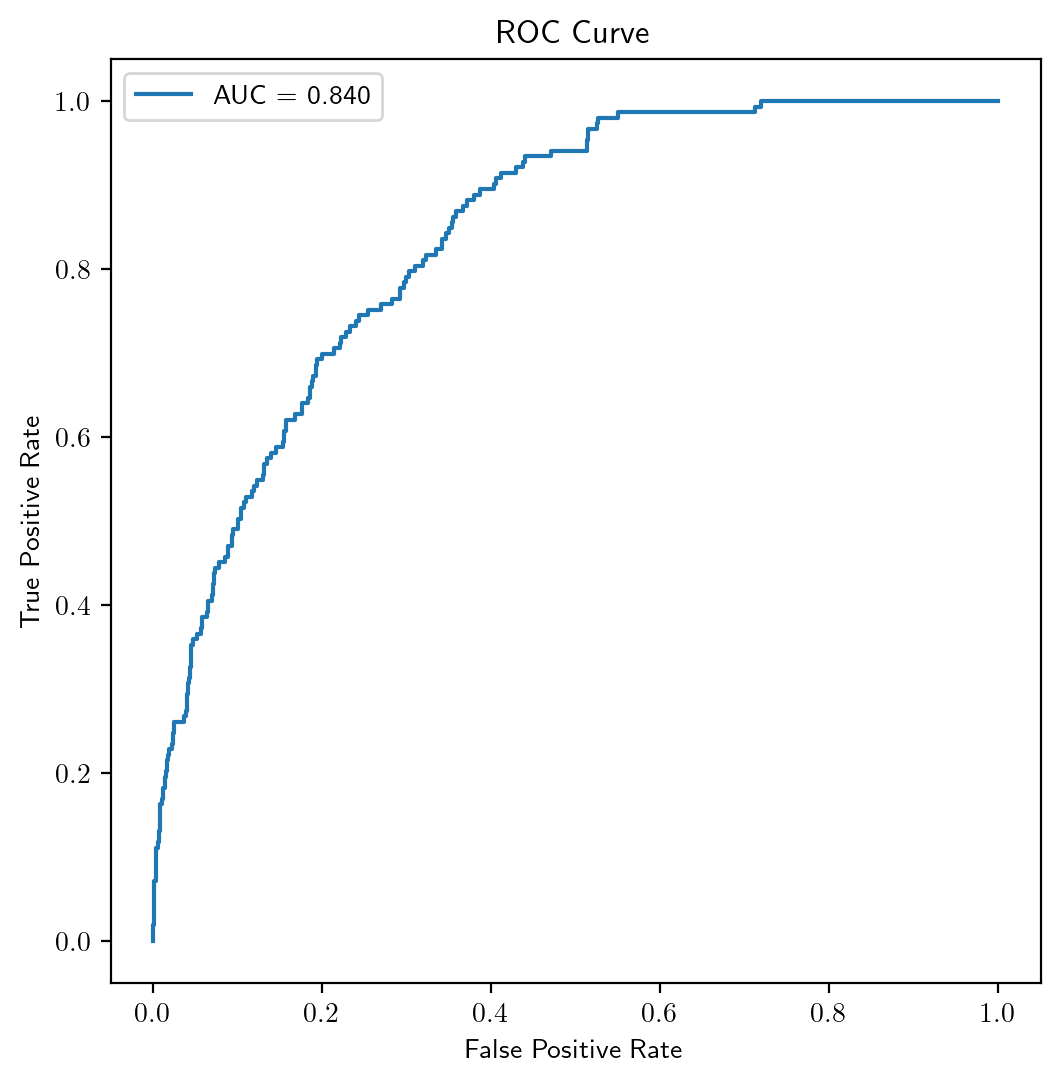

In [44]:
model = train_NN(neurons[np.argmax(cv_err)], traindataloader, traindata, testdata)
model.eval()

with torch.no_grad():
    X_test = testdata[:][0]
    y_test = testdata[:][1].numpy().ravel()

    logits = model(X_test)

    probs = torch.sigmoid(logits).numpy().ravel()

y_pred = (probs >= 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)
print(cm)

fpr, tpr, _ = roc_curve(y_test, probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

print("AUC =", roc_auc)